In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from prysm.propagation import prepare_executor
from prysm.segmented import VERTEX_TO_VERTEX_TO_FLAT_TO_FLAT
from prysm.mathops import set_backend_to_cupy, np, set_backend_to_defaults

from dygdug.masks import Pupil, FPM
from dygdug.coropt import VariablePupil
from dygdug.models import Coronagraph

from copy import deepcopy

from astropy.io import fits

from utils import make_pinwheel, make_pinwheel_eac2, radial_profile

%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
# Define instrument parameters
Dpup = 6e3
Npup = 1024
Nfoc = 128
wvl = 1
fno = 15
efl = fno * Dpup
lamD = wvl / Dpup * efl
px_per_lamD = 4

extent_pupil = [-Dpup / 2e3, Dpup / 2e3, 
                -Dpup / 2e3, Dpup / 2e3]
extent_focal = [-Nfoc / px_per_lamD / 2, Nfoc / px_per_lamD / 2,
                -Nfoc / px_per_lamD / 2, Nfoc / px_per_lamD / 2]

## throughputs

In [4]:
shifts = np.linspace(0, extent_focal[-1], 100)
throughput_aplc_pin = fits.getdata("/home/derbyk/src/wheelies/aplc_throughput_pinwheel.fits")
throughput_aplc_pin2 = fits.getdata("/home/derbyk/src/wheelies/aplc_throughput_pinwheel_big.fits")
throughput_aplc_cir = fits.getdata("/home/derbyk/src/wheelies/aplc_throughput_circ.fits")
throughput_paplc_pin = fits.getdata("/home/derbyk/src/wheelies/paplc_throughput_pinwheel.fits")
throughput_paplc_pin2 = fits.getdata("/home/derbyk/src/wheelies/paplc_throughput_pinwheel_big.fits")
throughput_paplc_cir = fits.getdata("/home/derbyk/src/wheelies/paplc_throughput_circ.fits")

<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3106450/1314296957.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\lambda/D$')


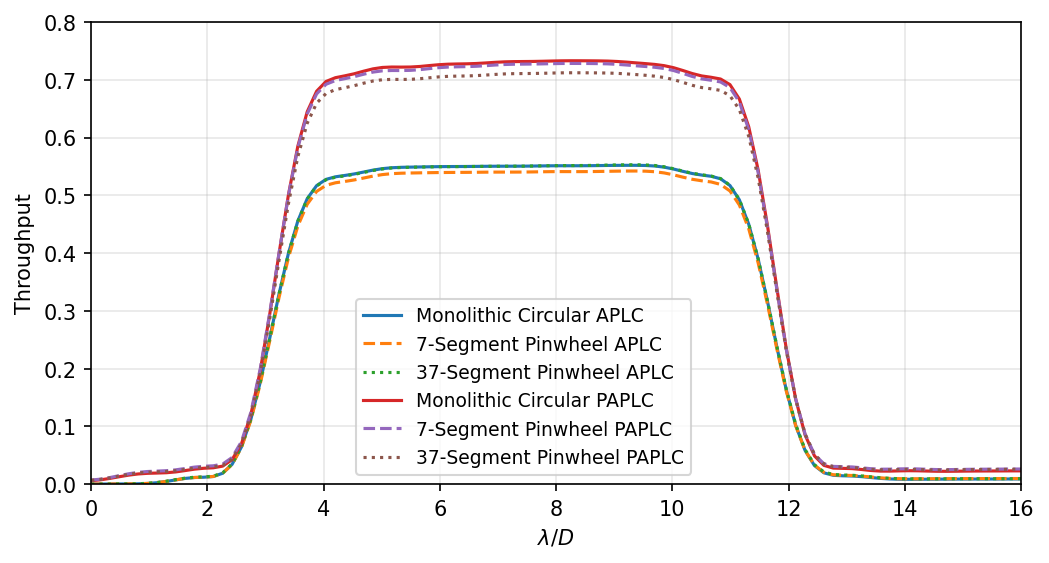

In [16]:
plt.figure(figsize=(8, 4), dpi=150)
plt.plot(shifts, throughput_aplc_cir, label='Monolithic Circular APLC')
plt.plot(shifts, throughput_aplc_pin, label='7-Segment Pinwheel APLC', linestyle='dashed')
plt.plot(shifts, throughput_aplc_pin2, label='37-Segment Pinwheel APLC', linestyle='dotted')
plt.plot(shifts, throughput_paplc_cir, label='Monolithic Circular PAPLC')
plt.plot(shifts, throughput_paplc_pin, label='7-Segment Pinwheel PAPLC', linestyle='dashed')
plt.plot(shifts, throughput_paplc_pin2, label='37-Segment Pinwheel PAPLC', linestyle='dotted')
plt.grid(which='both', alpha=0.3)
plt.xlabel('$\lambda/D$')
plt.ylabel('Throughput')
plt.xlim([0, shifts[-1]])
plt.ylim([0, 0.8])
# plt.legend(bbox_to_anchor=(1., 0.72), loc='upper left')
plt.legend(bbox_to_anchor=(0.465, 0), loc='lower center', fontsize=9)

## contrasts

In [14]:
psf_aplc_pin = fits.getdata("/home/derbyk/src/wheelies/aplc_psf_pinwheel.fits")
psf_aplc_pin2 = fits.getdata("/home/derbyk/src/wheelies/aplc_psf_pinwheel_big.fits")
psf_aplc_cir = fits.getdata("/home/derbyk/src/wheelies/aplc_psf_circ.fits")
psf_paplc_pin = fits.getdata("/home/derbyk/src/wheelies/paplc_psf_pinwheel.fits")
psf_paplc_pin2 = fits.getdata("/home/derbyk/src/wheelies/paplc_psf_pinwheel_big.fits")
psf_paplc_cir = fits.getdata("/home/derbyk/src/wheelies/paplc_psf_circ.fits")

<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3106450/1219104976.py:18: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\lambda/D$')


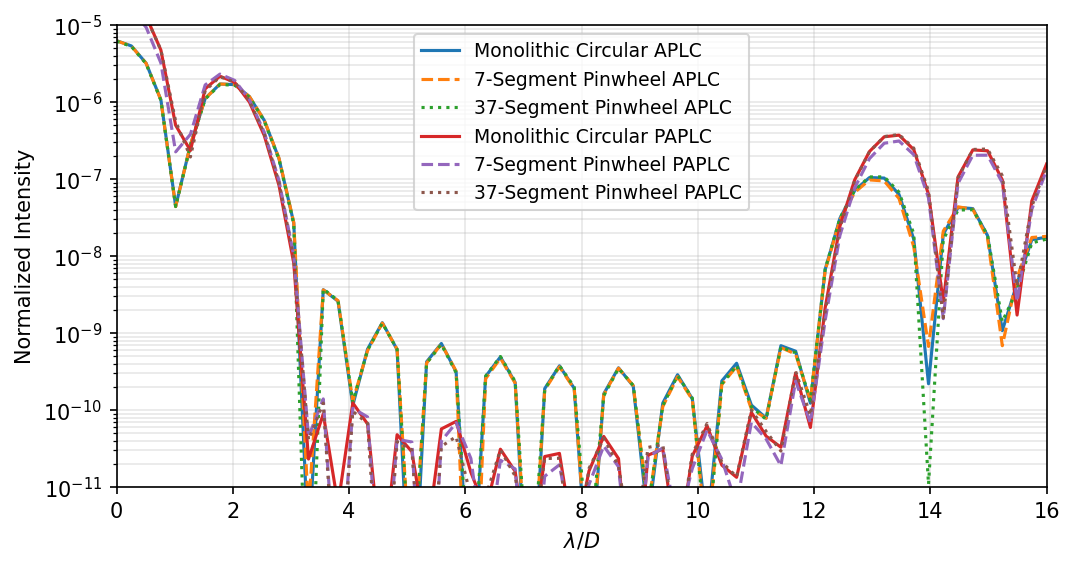

In [17]:
plt.figure(figsize=(8, 4), dpi=150)
plt.semilogy(np.linspace(0, extent_focal[-1], int(psf_aplc_cir.shape[0] / 2)), psf_aplc_cir[int(psf_aplc_cir.shape[0] / 2), int(psf_aplc_cir.shape[0] / 2):], 
             label='Monolithic Circular APLC')
plt.semilogy(np.linspace(0, extent_focal[-1], int(psf_aplc_cir.shape[0] / 2)), psf_aplc_pin[int(psf_aplc_pin.shape[0] / 2), int(psf_aplc_pin.shape[0] / 2):], 
             label='7-Segment Pinwheel APLC', linestyle='dashed')
plt.semilogy(np.linspace(0, extent_focal[-1], int(psf_aplc_cir.shape[0] / 2)), psf_aplc_pin2[int(psf_aplc_pin2.shape[0] / 2), int(psf_aplc_pin2.shape[0] / 2):], 
             label='37-Segment Pinwheel APLC', linestyle='dotted')
plt.semilogy(np.linspace(0, extent_focal[-1], int(psf_aplc_cir.shape[0] / 2)), psf_paplc_cir[int(psf_paplc_cir.shape[0] / 2), int(psf_paplc_cir.shape[0] / 2):], 
             label='Monolithic Circular PAPLC')
plt.semilogy(np.linspace(0, extent_focal[-1], int(psf_aplc_cir.shape[0] / 2)), psf_paplc_pin[int(psf_paplc_pin.shape[0] / 2), int(psf_paplc_pin.shape[0] / 2):], 
             label='7-Segment Pinwheel PAPLC', linestyle='dashed')
plt.semilogy(np.linspace(0, extent_focal[-1], int(psf_aplc_cir.shape[0] / 2)), psf_paplc_pin2[int(psf_paplc_pin2.shape[0] / 2), int(psf_paplc_pin2.shape[0] / 2):], 
             label='37-Segment Pinwheel PAPLC', linestyle='dotted')
plt.xlim([0, extent_focal[-1]])
plt.ylim([1e-11, 1e-5])

plt.grid(which='both', alpha=0.3)
plt.xlabel('$\lambda/D$')
plt.ylabel('Normalized Intensity')
# plt.legend(bbox_to_anchor=(1., 0.72), loc='upper left')
plt.legend(loc='upper center', fontsize=9)

## coro model stuff

In [3]:
set_backend_to_defaults()

pupil = VariablePupil.circle(
    Dpup=Dpup,
    Npup=Npup,
    mode="amplitude" # special argument for VariablePupil
)

set_backend_to_cupy()

pin37 = make_pinwheel(Dpup=Dpup, Npup=Npup, rings=3, segments_ring1=6, segment_separation=10).get()
pin7 = make_pinwheel_eac2(Npup=Npup, segment_separation=10).get()

# Define focal plane mask
fpm = FPM.annular(
    N=Nfoc,
    lamD=lamD,
    px_per_lamD=px_per_lamD,
    inner_radius=3,
    outer_radius=12,
)

# Define the lyot stop
lyot = Pupil.annular(
    Dpup=Dpup,
    Npup=Npup,
    inner_radius=0.,
    outer_radius=0.9 * Dpup / 2
)

/home/derbyk/miniconda3/envs/py312-prysm-env/lib/python3.12/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3809164/1346191051.py:6: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda/D$')


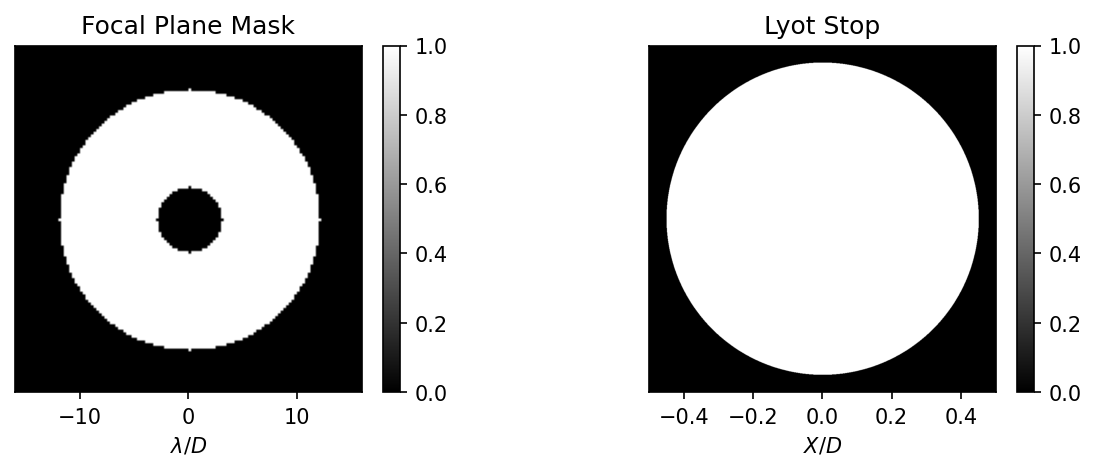

In [4]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(10, 3), dpi=150)

ax = axs[0]
ax.set_title("Focal Plane Mask")
im = ax.imshow(fpm(wvl).get(), cmap="gray", extent=extent_focal)
ax.set_xlabel('$\lambda/D$')
ax.set_yticklabels([])
ax.set_yticks([])
plt.colorbar(im, pad=0.04, fraction=0.046)

ax = axs[1]
ax.set_title("Lyot Stop")
im = ax.imshow(lyot.data.get(), cmap="gray", extent=[-0.5, 0.5, -0.5, 0.5])
ax.set_xlabel('$X/D$')
ax.set_yticklabels([])
ax.set_yticks([])
plt.colorbar(im, pad=0.04, fraction=0.046)

In [5]:
ap_aplc_pin = fits.getdata("/home/derbyk/src/wheelies/aplc_design_pinwheel.fits")
ap_aplc_pin2 = fits.getdata("/home/derbyk/src/wheelies/aplc_design_pinwheel_big.fits")
ap_aplc_cir = fits.getdata("/home/derbyk/src/wheelies/aplc_design_circ.fits")
ap_paplc_pin = fits.getdata("/home/derbyk/src/wheelies/paplc_design_pinwheel.fits")
ap_paplc_pin2 = fits.getdata("/home/derbyk/src/wheelies/paplc_design_pinwheel_big.fits")
ap_paplc_cir = fits.getdata("/home/derbyk/src/wheelies/paplc_design_circ.fits")

psf_aplc_pin = fits.getdata("/home/derbyk/src/wheelies/aplc_psf_pinwheel.fits")
psf_aplc_pin2 = fits.getdata("/home/derbyk/src/wheelies/aplc_psf_pinwheel_big.fits")
psf_aplc_cir = fits.getdata("/home/derbyk/src/wheelies/aplc_psf_circ.fits")
psf_paplc_pin = fits.getdata("/home/derbyk/src/wheelies/paplc_psf_pinwheel.fits")
psf_paplc_pin2 = fits.getdata("/home/derbyk/src/wheelies/paplc_psf_pinwheel_big.fits")
psf_paplc_cir = fits.getdata("/home/derbyk/src/wheelies/paplc_psf_circ.fits")

In [6]:
set_backend_to_defaults()

pupil = VariablePupil.circle(
    Dpup=Dpup,
    Npup=Npup,
    mode="amplitude" # special argument for VariablePupil
)

set_backend_to_cupy()

pin37 = make_pinwheel(Dpup=Dpup, Npup=Npup, rings=3, segments_ring1=6, segment_separation=10).get()
pin7 = make_pinwheel_eac2(Npup=Npup, segment_separation=10).get()

# Define focal plane mask
fpm = FPM.annular(
    N=Nfoc,
    lamD=lamD,
    px_per_lamD=px_per_lamD,
    inner_radius=3,
    outer_radius=12,
)

# Define the lyot stop
lyot = Pupil.annular(
    Dpup=Dpup,
    Npup=Npup,
    inner_radius=0.,
    outer_radius=0.9 * Dpup / 2
)

<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:52: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:52: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3809164/2894072294.py:16: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda/D$')
/tmp/ipykernel_3809164/2894072294.py:34: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda/D$')
/tmp/ipykernel_3809164/2894072294.py:52: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda/D$')


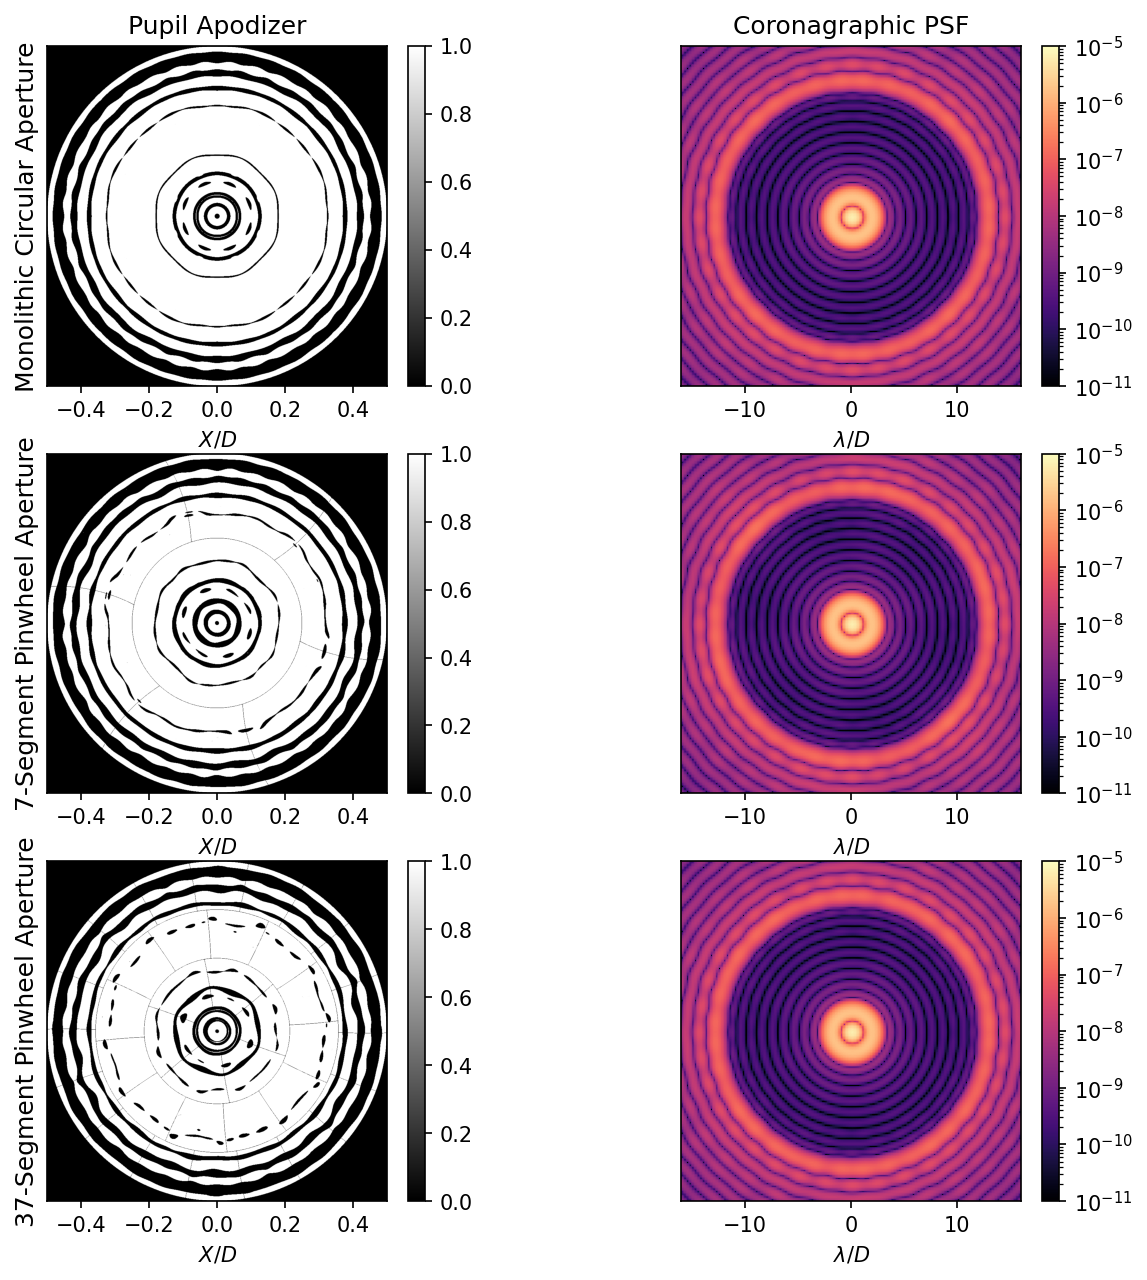

In [7]:
fig, axs = plt.subplots(ncols=2, nrows=3, figsize=(10, 10), dpi=150)

pupil.update(ap_aplc_cir)
ax = axs[0, 0]
ax.set_title("Pupil Apodizer")
im = ax.imshow(pupil.data, cmap="gray", extent=[-0.5, 0.5, -0.5, 0.5])
ax.set_xlabel('$X/D$')
ax.set_ylabel('Monolithic Circular Aperture', fontsize=12)
ax.set_yticklabels([])
ax.set_yticks([])
plt.colorbar(im, pad=0.04, fraction=0.046)

ax = axs[0, 1]
ax.set_title("Coronagraphic PSF")
im = ax.imshow(psf_aplc_cir, cmap="magma", extent=extent_focal, vmin=1e-11, vmax=1e-5, norm='log')
ax.set_xlabel('$\lambda/D$')
ax.set_yticklabels([])
ax.set_yticks([])
plt.colorbar(im, pad=0.04, fraction=0.046)

pupil.data = pin7
pupil.mask = (pin7 != 0)
pupil.update(ap_aplc_pin)
ax = axs[1, 0]
im = ax.imshow(pupil.data, cmap="gray", extent=[-0.5, 0.5, -0.5, 0.5])
ax.set_xlabel('$X/D$')
ax.set_ylabel('7-Segment Pinwheel Aperture', fontsize=12)
ax.set_yticklabels([])
ax.set_yticks([])
plt.colorbar(im, pad=0.04, fraction=0.046)

ax = axs[1, 1]
im = ax.imshow(psf_aplc_pin, cmap="magma", extent=extent_focal, vmin=1e-11, vmax=1e-5, norm='log')
ax.set_xlabel('$\lambda/D$')
ax.set_yticklabels([])
ax.set_yticks([])
plt.colorbar(im, pad=0.04, fraction=0.046)

pupil.data = pin37
pupil.mask = (pin37 != 0)
pupil.update(ap_aplc_pin2)
ax = axs[2, 0]
im = ax.imshow(pupil.data, cmap="gray", extent=[-0.5, 0.5, -0.5, 0.5])
ax.set_xlabel('$X/D$')
ax.set_ylabel('37-Segment Pinwheel Aperture', fontsize=12)
ax.set_yticklabels([])
ax.set_yticks([])
plt.colorbar(im, pad=0.04, fraction=0.046)

ax = axs[2, 1]
im = ax.imshow(psf_aplc_pin2, cmap="magma", extent=extent_focal, vmin=1e-11, vmax=1e-5, norm='log')
ax.set_xlabel('$\lambda/D$')
ax.set_yticklabels([])
ax.set_yticks([])
plt.colorbar(im, pad=0.04, fraction=0.046)

In [8]:
set_backend_to_defaults()

pupil = VariablePupil.circle(
    Dpup=Dpup,
    Npup=Npup,
    mode="phase" # special argument for VariablePupil
)

set_backend_to_cupy()

pin37 = make_pinwheel(Dpup=Dpup, Npup=Npup, rings=3, segments_ring1=6, segment_separation=10).get()
pin7 = make_pinwheel_eac2(Npup=Npup, segment_separation=10).get()

# Define focal plane mask
fpm = FPM.annular(
    N=Nfoc,
    lamD=lamD,
    px_per_lamD=px_per_lamD,
    inner_radius=3,
    outer_radius=12,
)

# Define the lyot stop
lyot = Pupil.annular(
    Dpup=Dpup,
    Npup=Npup,
    inner_radius=0.,
    outer_radius=0.9 * Dpup / 2
)

set_backend_to_defaults()

<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3809164/3405259564.py:16: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda/D$')
/tmp/ipykernel_3809164/3405259564.py:31: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda/D$')
/tmp/ipykernel_3809164/3405259564.py:46: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda/D$')


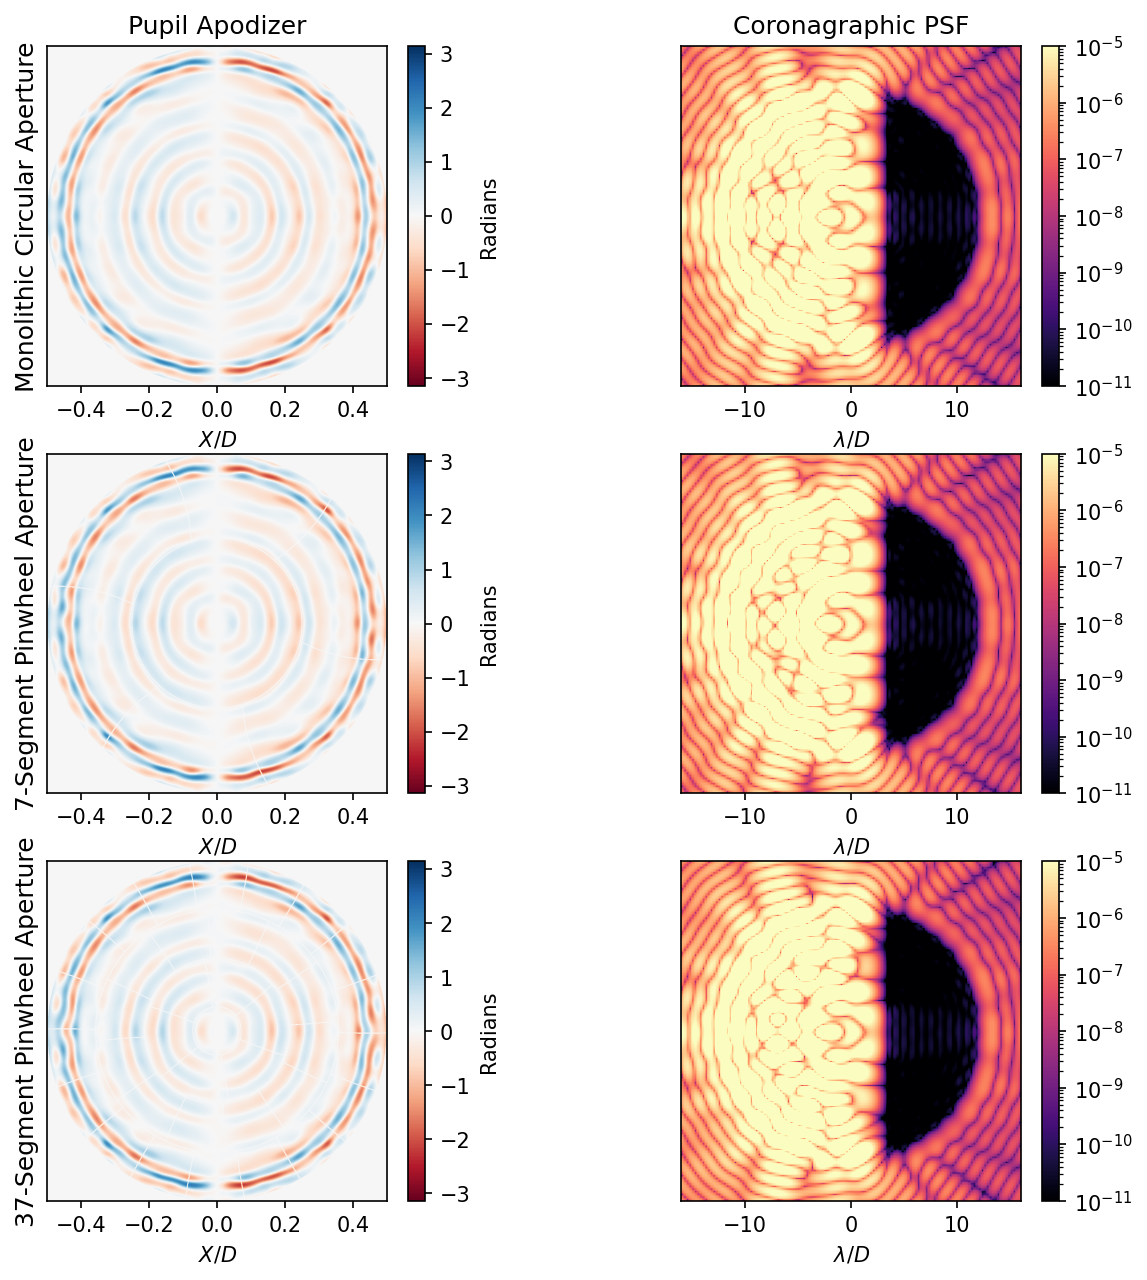

In [9]:
fig, axs = plt.subplots(ncols=2, nrows=3, figsize=(10, 10), dpi=150)

pupil.update(ap_paplc_cir)
ax = axs[0, 0]
ax.set_title("Pupil Apodizer")
im = ax.imshow(np.angle(pupil.data), cmap="RdBu", extent=[-0.5, 0.5, -0.5, 0.5], vmin=-np.pi, vmax=np.pi)
ax.set_xlabel('$X/D$')
ax.set_ylabel('Monolithic Circular Aperture', fontsize=12)
ax.set_yticklabels([])
ax.set_yticks([])
plt.colorbar(im, pad=0.04, fraction=0.046, label='Radians')

ax = axs[0, 1]
ax.set_title("Coronagraphic PSF")
im = ax.imshow(psf_paplc_cir, cmap="magma", extent=extent_focal, vmin=1e-11, vmax=1e-5, norm='log')
ax.set_xlabel('$\lambda/D$')
ax.set_yticklabels([])
ax.set_yticks([])
plt.colorbar(im, pad=0.04, fraction=0.046)

ax = axs[1, 0]
im = ax.imshow(ap_paplc_pin, cmap="RdBu", extent=[-0.5, 0.5, -0.5, 0.5], vmin=-np.pi, vmax=np.pi)
ax.set_xlabel('$X/D$')
ax.set_ylabel('7-Segment Pinwheel Aperture', fontsize=12)
ax.set_yticklabels([])
ax.set_yticks([])
plt.colorbar(im, pad=0.04, fraction=0.046, label='Radians')

ax = axs[1, 1]
im = ax.imshow(psf_paplc_pin, cmap="magma", extent=extent_focal, vmin=1e-11, vmax=1e-5, norm='log')
ax.set_xlabel('$\lambda/D$')
ax.set_yticklabels([])
ax.set_yticks([])
plt.colorbar(im, pad=0.04, fraction=0.046)

ax = axs[2, 0]
im = ax.imshow(ap_paplc_pin2, cmap="RdBu", extent=[-0.5, 0.5, -0.5, 0.5], vmin=-np.pi, vmax=np.pi)
ax.set_xlabel('$X/D$')
ax.set_ylabel('37-Segment Pinwheel Aperture', fontsize=12)
ax.set_yticklabels([])
ax.set_yticks([])
plt.colorbar(im, pad=0.04, fraction=0.046, label='Radians')

ax = axs[2, 1]
im = ax.imshow(psf_paplc_pin2, cmap="magma", extent=extent_focal, vmin=1e-11, vmax=1e-5, norm='log')
ax.set_xlabel('$\lambda/D$')
ax.set_yticklabels([])
ax.set_yticks([])
plt.colorbar(im, pad=0.04, fraction=0.046)